In [ ]:
import pyflextrkr.ft_utilities as ft

In [1]:
import numpy as np
import xarray as xr
import pyproj
from pyresample.geometry import SwathDefinition
import pyresample.kd_tree as kd_tree
from pyresample import get_area_def

In [34]:
data = xr.open_mfdataset("/wolke_scratch/dnikolo/CLAAS_Data/Resampled_Data/np/2010/01/01/Agg_03_*.nc")

In [78]:
class ProjectionTransformer():
    def generate_lat_lon_prj(self, aux_data):
        # Import lat and longitude matrixes taht indicate the corresponding latitude and longitude of each data within the field
        lon_mat, lat_mat = aux_data["lon"][0, :, :].values, aux_data["lat"][0, :, :].values

        # Generate variables needed for the later reshaping of the data
        self.bounds = [np.nanmin(lon_mat.astype(np.float64)), np.nanmax(lon_mat.astype(
            np.float64)), np.nanmin(lat_mat.astype(np.float64)), np.nanmax(lat_mat.astype(np.float64))]
        print(f"Bounds = {self.bounds}")
        Proj4Args = '+proj=eqc +lat_ts=0 +lat_0=0 +lon_0=0 +x_0=0 +y_0=0 +a=6378.137 +b=6378.137 +units=km'
        Prj = pyproj.Proj(Proj4Args)
        AreaID = 'cyl'
        AreaName = 'cyl'
        ProjID = 'cyl'
        # print(np.nanmin(lon_mat.astype(np.float64)),np.nanmin(lat_mat.astype(np.float64)))
        self.ny, self.nx = (52,160)
        # Get the projected poisions of the mst South West and North ast points: Usually outputs sth in the range 5-15
        # I have no idea how it works acually but it works so I wont question it
        SW = Prj(self.bounds[0], self.bounds[2])
        NW = Prj(self.bounds[1], self.bounds[3])
        area_extent = [SW[0], SW[1], NW[0], NW[1]]
        # print(area_extent)
        # The transformation in remap_data transforms th data from SwathDef to AreaDef
        self.AreaDef = get_area_def(
            AreaID, AreaName, ProjID, Proj4Args, self.nx, self.ny, area_extent)
        self.SwathDef = SwathDefinition(lons=lon_mat, lats=lat_mat)

        self._generate_new_coordinates()

    def _generate_new_coordinates(self):
        self.new_cord_lon = np.linspace(
            self.bounds[0], self.bounds[1], self.nx)
        self.new_cord_lat = np.linspace(
            self.bounds[2], self.bounds[3], self.ny)

    def remap_data(self, var_field, n_resample_procs=8):
        # Satellite height
        if self.SwathDef == None:
            raise Exception(
                "Error: No projection parameters generated. To generate run Projection_transformer_instance.generate_lat_lon_prj().")
        output_field = np.empty(var_field.shape)
        if len(var_field.shape) == 3:
            if set(var_field.dims) == set(["time", "lon", "lat"]):
                # output_field = kd_tree.resample_nearest(self.SwathDef, var_field.transpose("lat", "lon", "time").values, self.AreaDef, radius_of_influence=60000,
                #                                         fill_value=-1, epsilon=5, nprocs=n_resample_procs)  # reduce_data=True
                ## resamle gauss has an api bug
                # output_field = kd_tree.resample_gauss(self.SwathDef, var_field.transpose("lat", "lon", "time").values, self.AreaDef, radius_of_influence=60000 , sigmas=2,
                #                                         fill_value=-1, epsilon=5, nprocs=n_resample_procs)  # reduce_data=True
                def gauss(sigma):
                    # Return gauss function object
                    return lambda r: np.exp(-r ** 2 / float(sigma) ** 2)
                weight_func = gauss(2)  # your sigma
                output_field = kd_tree.resample_custom(
                    self.SwathDef,
                    var_field.transpose("lat", "lon", "time").values,
                    self.AreaDef,
                    radius_of_influence=60000,
                    epsilon=5,
                    fill_value=-1,
                    nprocs=n_resample_procs,
                    # IMPORTANT: pass a tuple (distance_func, weight_func)
                    weight_funcs=(None, weight_func),
                )
                
            elif set(var_field.dims) == set(["time", "x", "y"]):
                output_field = kd_tree.resample_nearest(self.SwathDef, var_field.transpose("y", "x", "time").values, self.AreaDef, radius_of_influence=60000,
                                                        fill_value=-1, epsilon=5, nprocs=n_resample_procs)  # reduce_data=True
            else:
                raise Exception(
                    f"Error: Unrecognized dimension names {var_field.dims}. Supported dimension names are ['time','lon','lat'] or ['time','x','y']")
            output_field = output_field.transpose(2, 0, 1)
            output_field = np.flip(output_field,1)
            output_field[np.isnan(output_field)] = -1
            return output_field
        else:
            raise NotImplementedError("2D var field remapping not yet added")


In [79]:
transformer = ProjectionTransformer()
aux_data = xr.open_dataset(
    "/wolke_scratch/dnikolo/processed_daily/np/aggregated_aux_file_lat_lon.nc",decode_times=False)
transformer.generate_lat_lon_prj(aux_data)

Bounds = [-79.10257992081108, 79.10187888213846, 26.060756309323498, 80.43311061944385]


In [80]:
out_field = transformer.remap_data(data["ctt_resampled"])

TypeError: weight_func must be function object

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plot_field = out_field.copy()
plot_field[plot_field==-1] = np.nan

In [ ]:
np.average(transformer.new_cord_lon[1:]-transformer.new_cord_lon[:-1])

0.9949965962449657

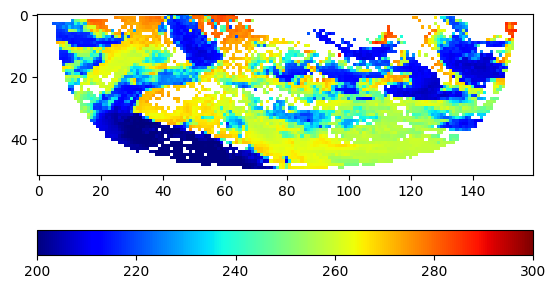

In [ ]:
plt.imshow(plot_field[0], cmap='jet',vmin=200,vmax=300)
plt.colorbar(location='bottom')